# Mestrado em Inteligência Artificial 25/26


# Practical 3 — Dynamic Programming (Gridworld)
## Policy Improvement & Policy Iteration


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'agents').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.mplconfig'))

from envs.gridworld import Gridworld
from experiments.gridworld_dp import (
    greedy_action_from_V,
    policy_evaluation,
    policy_improvement,
    policy_iteration,
    zeros_V,
)
from plots.gridworld import plot_grid_values_and_policy
from policies.gridworld import uniform_random_policy

np.set_printoptions(precision=3, suppress=True)


In [2]:
env = Gridworld()
env.states()[:5], env.terminal_states


([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

## Utils


In [3]:
V0 = zeros_V(env)
V0


array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

### Policy


In [4]:
pi0 = uniform_random_policy(env)
pi0[(1, 1)]


{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

## Policy Evaluation (given a fixed policy)


In [5]:
gamma = 0.9
V_pi0, iters = policy_evaluation(env, pi0, gamma=gamma)
print('Policy evaluation converged in iterations:', iters)
V_pi0


Policy evaluation converged in iterations: 89


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

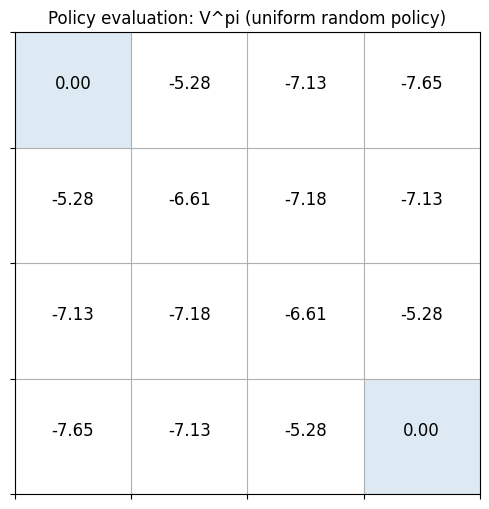

In [6]:
fig, ax = plot_grid_values_and_policy(
    env,
    V_pi0,
    policy=None,
    title='Policy evaluation: V^pi (uniform random policy)',
)
plt.show()


## Policy Improvement


In [7]:
greedy_action_from_V(env, V_pi0, (1, 1), gamma=gamma)


'U'

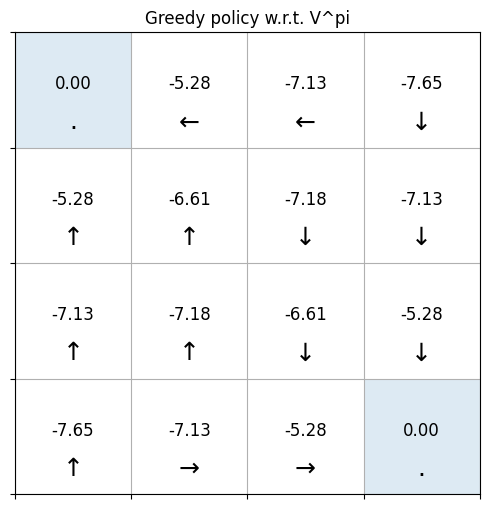

In [8]:
pi1_actions, _ = policy_improvement(env, V_pi0, old_policy_actions=None, gamma=gamma)
fig, ax = plot_grid_values_and_policy(
    env,
    V_pi0,
    policy=pi1_actions,
    title='Greedy policy w.r.t. V^pi',
)
plt.show()


## Policy Iteration


In [9]:
V_star, pi_star_actions, hist = policy_iteration(env, gamma=gamma)
print('Policy iteration outer loops:', len(hist))
V_star


Policy iteration outer loops: 3


array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

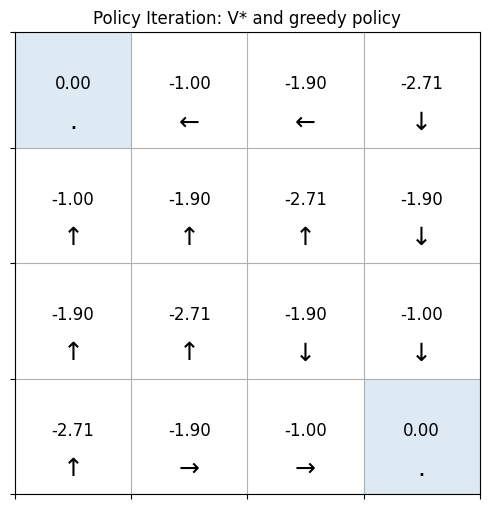

In [10]:
fig, ax = plot_grid_values_and_policy(
    env,
    V_star,
    policy=pi_star_actions,
    title='Policy Iteration: V* and greedy policy',
)
plt.show()


In [11]:
pi_star_actions


{(0, 0): '.',
 (0, 1): 'L',
 (0, 2): 'L',
 (0, 3): 'D',
 (1, 0): 'U',
 (1, 1): 'U',
 (1, 2): 'U',
 (1, 3): 'D',
 (2, 0): 'U',
 (2, 1): 'U',
 (2, 2): 'D',
 (2, 3): 'D',
 (3, 0): 'U',
 (3, 1): 'R',
 (3, 2): 'R',
 (3, 3): '.'}

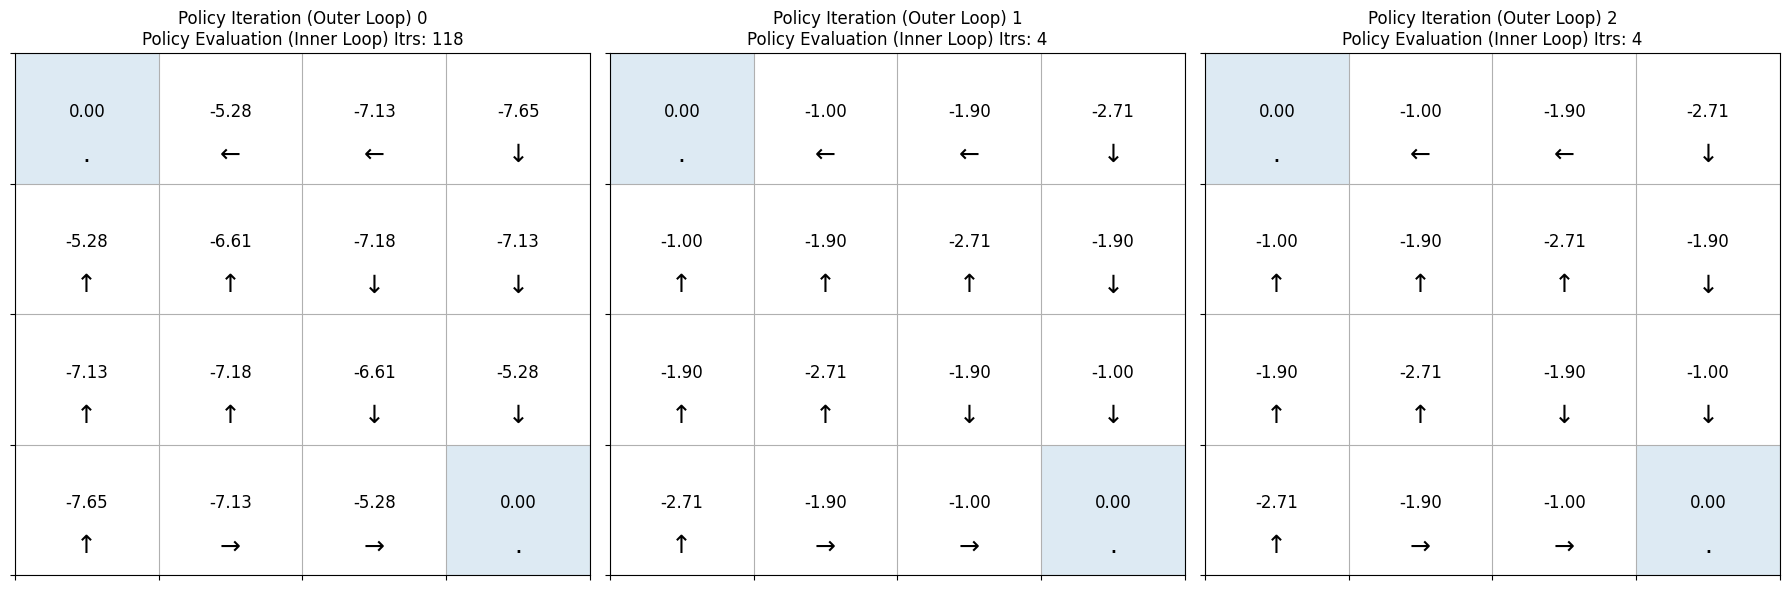

In [13]:
num_plots = len(hist)
fig, axes = plt.subplots(1, num_plots, figsize=(num_plots * 6, 6))
if num_plots == 1:
    axes = [axes]

for i, (outer_iter, pe_iters, V_hist, pi_actions_hist) in enumerate(hist):
    plot_grid_values_and_policy(
        env,
        V_hist,
        policy=pi_actions_hist,
        title=f'Policy Iteration (Outer Loop) {outer_iter}\nPolicy Evaluation (Inner Loop) Itrs: {pe_iters}',
        ax=axes[i],
    )

plt.tight_layout()
plt.show()
